  cancelled contract length  days active  invites sent  money spent  \
0        no         monthly          143             1          456   
1        no         monthly           43            14         1068   
2        no         monthly           31            12          105   
3        no          annual           31            17          811   
4        no         monthly           19             4          970   

            occupation used coupon code  user ID  
0  engineering manager              yes     3001  
1            developer               no     3002  
2      product manager               no     3003  
3      product manager               no     3004  
4            developer               no     3005  
<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   cancelled         7000 non-null   str  
 1   contract length   7000 non-null 

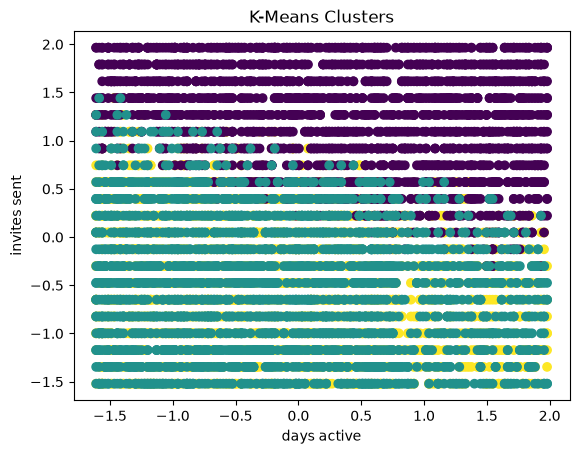

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_4213/1767618776.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns



NLP Cluster counts:
NLP_Cluster
1    2984
2    2053
0    1963
Name: count, dtype: int64

Done!


,cancelled,contract length,days active,invites sent,money spent,occupation,used coupon code,user ID,Cluster,NLP_Cluster
0,no,monthly,143,1,456,engineering manager,yes,3001,2,2
1,no,monthly,43,14,1068,developer,no,3002,2,1
2,no,monthly,31,12,105,product manager,no,3003,2,0
3,no,annual,31,17,811,product manager,no,3004,0,0
4,no,monthly,19,4,970,developer,no,3005,2,1


In [1]:
# K-MEANS + NLP - Membership Subscriptions

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

# Load data
df = pd.read_csv("membership_subscriptions.csv")
print(df.head())
print(df.info())

# ---------------- K-MEANS ----------------

# Select numerical columns
num = df.select_dtypes(include="number").columns
X = df[num].fillna(df[num].median())

# Scale data
X = StandardScaler().fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

print("\nCluster counts:")
print(df["Cluster"].value_counts())

# Plot
if len(num) >= 2:
    plt.scatter(X[:, 0], X[:, 1], c=df["Cluster"])
    plt.xlabel(num[0])
    plt.ylabel(num[1])
    plt.title("K-Means Clusters")
    plt.show()

# ---------------- NLP ----------------

# Find text columns
text_cols = df.select_dtypes(include="object").columns

if len(text_cols) > 0:
    text = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

    # TF-IDF
    tfidf = TfidfVectorizer(stop_words="english")
    X_text = tfidf.fit_transform(text)

    # NLP K-Means
    nlp = KMeans(n_clusters=3, random_state=42, n_init=10)
    df["NLP_Cluster"] = nlp.fit_predict(X_text)

    print("\nNLP Cluster counts:")
    print(df["NLP_Cluster"].value_counts())

# Save results
df.to_csv("membership_subscriptions_clustered.csv", index=False)

print("\nDone!")
display(df.head())